In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
pd.set_option("display.max_columns",None)   #display all columns when viewing dataframe

In [4]:
subscribers = pd.read_csv("Data/subscribers.csv")
titles = pd.read_csv("Data/titles.csv")
watch_history = pd.read_csv("Data/watch_history.csv")
ratings = pd.read_csv("Data/ratings.csv")
reviews = pd.read_csv("Data/reviews.csv")
watchlist = pd.read_csv("Data/watchlist.csv")

In [5]:
print("Subsribers",subscribers.shape)
print("Titles",titles.shape)
print("watch history",watch_history.shape)
print("ratings",ratings.shape)
print("reviews",reviews.shape)
print("watchlist",watchlist.shape)

#view all how many col and rows 

Subsribers (15000, 14)
Titles (9000, 21)
watch history (650000, 10)
ratings (130000, 5)
reviews (110000, 7)
watchlist (65000, 5)


In [6]:
subscribers.head()




,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date
0,SUB100000,2023-01-09,France,Europe,22,Female,Basic with Ads,6.99,1,Mobile,Credit Card,41,True,NaN
1,SUB100001,2020-02-05,United Kingdom,Europe,48,Male,Basic with Ads,6.99,1,Smart TV,Credit Card,76,False,2022-12-08
2,SUB100002,2022-04-15,Italy,Europe,35,Male,Standard,15.49,2,Streaming Stick,Gift Card,50,True,NaN
3,SUB100003,2024-10-10,Spain,Europe,49,Female,Basic with Ads,6.99,1,Laptop,Credit Card,19,True,NaN
4,SUB100004,2020-04-12,United States,North America,36,Female,Basic with Ads,6.99,1,Mobile,Credit Card,74,False,2021-12-15


In [8]:
titles.head()

,title_id,title_name,type,primary_genre,country,language,release_year,date_added,maturity_rating,seasons,content_duration_min,is_original,license_type,director,cast,quality_score,popularity_score,license_cost_usd,license_expiry,total_watch_hours,total_plays
0,TTL200000,Toronto Requiem,TV Show,Comedy,South Korea,Korean,2026,2026-04-05,R,6,2754,True,Original,Ravi Nguyen,"Rosa Ferrari, Aria Cohen, Nina Kim, Felix Santos",68.6,0.19,7965521,NaN,1300.8,44
1,TTL200001,Seoul Inheritance,TV Show,Fantasy,South Korea,Korean,2026,2026-05-01,TV-MA,4,2552,False,Non-Exclusive License,Greta Sharma,"Priya Ferrari, Lucia Mehta, Ravi Yilmaz, Joon ...",89.4,0.29,3074516,2028-08-03,1767.2,52
2,TTL200002,Tender Paradox,TV Show,Horror,Italy,Italian,2026,2026-04-17,PG,3,324,False,Non-Exclusive License,Bruno Moreau,"Elena Park, Aria Romano, Omar Olsen, Chloe Nak...",37.3,0.20,629307,2027-02-16,166.5,60
3,TTL200003,Velvet Expedition,Movie,Animation,India,Hindi,1985,2018-12-08,TV-14,0,47,False,Non-Exclusive License,Owen Mwangi,"Ava Russo, Clara Fischer, Zoe Khan, Rosa Reyes",37.8,0.02,1345769,2029-10-11,16.2,43
4,TTL200004,The Shadows of Lisbon,Movie,Animation,India,Hindi,1991,2016-05-11,TV-14,0,66,False,Exclusive License,Joon Kim,"Hana Patel, Fatima Patel, Hassan Reyes, Liam L...",78.0,0.00,1696493,2028-11-21,35.7,43


In [9]:
watch_history.head()


,watch_id,subscriber_id,title_id,watch_date,device,region,content_duration_min,watch_duration_min,completion_pct,completed
0,1,SUB107630,TTL205207,2024-01-01,Smart TV,East Asia,888,826.7,93.1,True
1,2,SUB114773,TTL204889,2025-10-18,Mobile,South Asia,2340,1866.4,79.8,False
2,3,SUB106013,TTL206882,2026-04-26,Mobile,Latin America,656,75.0,11.4,False
3,4,SUB100939,TTL208849,2026-03-09,Mobile,North America,500,493.2,98.6,True
4,5,SUB107223,TTL202529,2023-12-27,Tablet,North America,141,94.6,67.1,False


In [10]:
ratings.head()

,rating_id,subscriber_id,title_id,rating,rating_date
0,1,SUB109184,TTL203909,4,2026-02-06
1,2,SUB105194,TTL200888,4,2025-03-21
2,3,SUB102974,TTL200036,3,2024-05-26
3,4,SUB105612,TTL206358,5,2026-05-22
4,5,SUB103070,TTL205227,4,2026-05-16


In [11]:
reviews.head()

,review_id,subscriber_id,title_id,review_text,sentiment,helpful_votes,review_date
0,1,SUB102409,TTL206425,Stellar cast and a satisfying ending.,Positive,9,2023-11-04
1,2,SUB111270,TTL203987,Predictable plot and flat characters.,Negative,4,2026-04-25
2,3,SUB107848,TTL203235,"Started strong, lost steam in the middle.",Neutral,2,2024-07-31
3,4,SUB114501,TTL200930,Beautifully shot and emotionally resonant.,Positive,14,2022-12-13
4,5,SUB113370,TTL207141,A rare gem. Highly recommend.,Positive,6,2025-10-09


In [12]:
watchlist.head()

,watchlist_id,subscriber_id,title_id,added_date,watched
0,1,SUB104004,TTL201827,2023-06-05,True
1,2,SUB102310,TTL201354,2023-01-31,False
2,3,SUB111860,TTL204871,2022-06-21,True
3,4,SUB113333,TTL205130,2023-12-23,True
4,5,SUB106850,TTL204396,2022-02-02,False


In [13]:
#check structure
subscribers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subscriber_id      15000 non-null  object 
 1   signup_date        15000 non-null  object 
 2   country            15000 non-null  object 
 3   region             15000 non-null  object 
 4   age                15000 non-null  int64  
 5   gender             15000 non-null  object 
 6   plan_type          15000 non-null  object 
 7   monthly_price_usd  15000 non-null  float64
 8   household_size     15000 non-null  int64  
 9   primary_device     15000 non-null  object 
 10  payment_method     15000 non-null  object 
 11  tenure_months      15000 non-null  int64  
 12  is_active          15000 non-null  bool   
 13  churn_date         3801 non-null   object 
dtypes: bool(1), float64(1), int64(3), object(9)
memory usage: 1.5+ MB


In [14]:
titles.info()

watch_history.info()

ratings.info()

reviews.info()

watchlist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title_id              9000 non-null   object 
 1   title_name            9000 non-null   object 
 2   type                  9000 non-null   object 
 3   primary_genre         9000 non-null   object 
 4   country               9000 non-null   object 
 5   language              9000 non-null   object 
 6   release_year          9000 non-null   int64  
 7   date_added            9000 non-null   object 
 8   maturity_rating       9000 non-null   object 
 9   seasons               9000 non-null   int64  
 10  content_duration_min  9000 non-null   int64  
 11  is_original           9000 non-null   bool   
 12  license_type          9000 non-null   object 
 13  director              9000 non-null   object 
 14  cast                  9000 non-null   object 
 15  quality_score        

In [15]:
#check missing values

subscribers.isnull().sum()

subscriber_id            0
signup_date              0
country                  0
region                   0
age                      0
gender                   0
plan_type                0
monthly_price_usd        0
household_size           0
primary_device           0
payment_method           0
tenure_months            0
is_active                0
churn_date           11199
dtype: int64

In [16]:
titles.isnull().sum()



title_id                   0
title_name                 0
type                       0
primary_genre              0
country                    0
language                   0
release_year               0
date_added                 0
maturity_rating            0
seasons                    0
content_duration_min       0
is_original                0
license_type               0
director                   0
cast                       0
quality_score              0
popularity_score           0
license_cost_usd           0
license_expiry          1966
total_watch_hours          0
total_plays                0
dtype: int64

In [17]:

watch_history.isnull().sum()



watch_id                0
subscriber_id           0
title_id                0
watch_date              0
device                  0
region                  0
content_duration_min    0
watch_duration_min      0
completion_pct          0
completed               0
dtype: int64

In [18]:
ratings.isnull().sum()



rating_id        0
subscriber_id    0
title_id         0
rating           0
rating_date      0
dtype: int64

In [29]:
reviews.isnull().sum()


review_id        0
subscriber_id    0
title_id         0
review_text      0
sentiment        0
helpful_votes    0
review_date      0
dtype: int64

In [31]:

watchlist.isnull().sum()

watchlist_id     0
subscriber_id    0
title_id         0
added_date       0
watched          0
dtype: int64

In [33]:
# DATA CLEANING

#CONVERT ALL DATES INTO DATETIME
subscribers["signup_date"]= pd.to_datetime(subscribers["signup_date"])
subscribers["churn_date"]=pd.to_datetime(subscribers["churn_date"])

titles["date_added "] = pd.to_datetime(titles["date_added"])

watch_history["watch_date"] = pd.to_datetime(watch_history["watch_date"])

In [34]:
ratings["rating_date"] = pd.to_datetime(ratings["rating_date"])

# Reviews
reviews["review_date"] = pd.to_datetime(reviews["review_date"])

# Watchlist
watchlist["added_date"] = pd.to_datetime(watchlist["added_date"])

In [35]:
subscribers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscriber_id      15000 non-null  object        
 1   signup_date        15000 non-null  datetime64[ns]
 2   country            15000 non-null  object        
 3   region             15000 non-null  object        
 4   age                15000 non-null  int64         
 5   gender             15000 non-null  object        
 6   plan_type          15000 non-null  object        
 7   monthly_price_usd  15000 non-null  float64       
 8   household_size     15000 non-null  int64         
 9   primary_device     15000 non-null  object        
 10  payment_method     15000 non-null  object        
 11  tenure_months      15000 non-null  int64         
 12  is_active          15000 non-null  bool          
 13  churn_date         3801 non-null   datetime64[ns]
dtypes: boo

In [36]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   title_id              9000 non-null   object        
 1   title_name            9000 non-null   object        
 2   type                  9000 non-null   object        
 3   primary_genre         9000 non-null   object        
 4   country               9000 non-null   object        
 5   language              9000 non-null   object        
 6   release_year          9000 non-null   int64         
 7   date_added            9000 non-null   object        
 8   maturity_rating       9000 non-null   object        
 9   seasons               9000 non-null   int64         
 10  content_duration_min  9000 non-null   int64         
 11  is_original           9000 non-null   bool          
 12  license_type          9000 non-null   object        
 13  director          

In [37]:
#find invalid recrords where churn-DATE IS before signup date

invalid_churn = subscribers[(subscribers["churn_date"].notna()) &
                           (subscribers["churn_date"]<subscribers["signup_date"])]

print("no of invalid records",len(invalid_churn))
invalid_churn.head()

no of invalid records 0


,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date


In [39]:
subscribers["is_active"].value_counts()

True     11199
False     3801
Name: is_active, dtype: int64

In [40]:
active_with_churn= subscribers[
    (subscribers["is_active"]==True)&
    (subscribers["churn_date"].notna())
]
print("no of acctive subscribers with churn date ",len(active_with_churn))
active_with_churn.head()

no of acctive subscribers with churn date  0


,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date


In [19]:
watch_history.head()

,watch_id,subscriber_id,title_id,watch_date,device,region,content_duration_min,watch_duration_min,completion_pct,completed
0,1,SUB107630,TTL205207,2024-01-01,Smart TV,East Asia,888,826.7,93.1,True
1,2,SUB114773,TTL204889,2025-10-18,Mobile,South Asia,2340,1866.4,79.8,False
2,3,SUB106013,TTL206882,2026-04-26,Mobile,Latin America,656,75.0,11.4,False
3,4,SUB100939,TTL208849,2026-03-09,Mobile,North America,500,493.2,98.6,True
4,5,SUB107223,TTL202529,2023-12-27,Tablet,North America,141,94.6,67.1,False


In [21]:
#Calculate expected completion %

watch_history["calculated_completion_pct"]=(
watch_history["watch_duration_min"] / watch_history["content_duration_min"]*100)

#round to 1 decimal place (same as dataset)
watch_history["calculated_completion_pct"]=watch_history["calculated_completion_pct"].round(1)

watch_history.head()

,watch_id,subscriber_id,title_id,watch_date,device,region,content_duration_min,watch_duration_min,completion_pct,completed,calculated_completion_pct
0,1,SUB107630,TTL205207,2024-01-01,Smart TV,East Asia,888,826.7,93.1,True,93.1
1,2,SUB114773,TTL204889,2025-10-18,Mobile,South Asia,2340,1866.4,79.8,False,79.8
2,3,SUB106013,TTL206882,2026-04-26,Mobile,Latin America,656,75.0,11.4,False,11.4
3,4,SUB100939,TTL208849,2026-03-09,Mobile,North America,500,493.2,98.6,True,98.6
4,5,SUB107223,TTL202529,2023-12-27,Tablet,North America,141,94.6,67.1,False,67.1


In [23]:
#Compare the values

invalid_completion = watch_history[ watch_history["completion_pct"]!= watch_history["calculated_completion_pct"]]

print("number of invalid records",len(invalid_completion))
invalid_completion.head()

number of invalid records 100507


,watch_id,subscriber_id,title_id,watch_date,device,region,content_duration_min,watch_duration_min,completion_pct,completed,calculated_completion_pct
7,8,SUB104186,TTL201043,2026-04-26,Tablet,North America,91,58.6,64.3,False,64.4
9,10,SUB100907,TTL208278,2025-04-16,Mobile,North America,81,61.6,76.1,False,76.0
14,15,SUB112834,TTL204631,2026-05-20,Mobile,South Asia,70,35.7,51.1,False,51.0
17,18,SUB105406,TTL206245,2026-04-04,Tablet,South Asia,87,27.0,31.1,False,31.0
22,23,SUB106103,TTL204075,2026-04-30,Smart TV,North America,109,104.6,95.9,True,96.0


In [24]:
#inspect invalid records

invalid_completion.head(10)

,watch_id,subscriber_id,title_id,watch_date,device,region,content_duration_min,watch_duration_min,completion_pct,completed,calculated_completion_pct
7,8,SUB104186,TTL201043,2026-04-26,Tablet,North America,91,58.6,64.3,False,64.4
9,10,SUB100907,TTL208278,2025-04-16,Mobile,North America,81,61.6,76.1,False,76.0
14,15,SUB112834,TTL204631,2026-05-20,Mobile,South Asia,70,35.7,51.1,False,51.0
17,18,SUB105406,TTL206245,2026-04-04,Tablet,South Asia,87,27.0,31.1,False,31.0
22,23,SUB106103,TTL204075,2026-04-30,Smart TV,North America,109,104.6,95.9,True,96.0
32,33,SUB113626,TTL203510,2026-04-23,Smart TV,Europe,122,103.5,84.9,False,84.8
40,41,SUB101441,TTL206026,2026-05-31,Mobile,North America,128,95.8,74.9,False,74.8
41,42,SUB100923,TTL207421,2026-04-19,Smart TV,East Asia,101,88.7,87.9,False,87.8
49,50,SUB106574,TTL203138,2026-05-20,Smart TV,Europe,130,102.2,78.7,False,78.6
53,54,SUB104744,TTL202107,2026-05-07,Mobile,North America,126,11.0,8.8,False,8.7


In [26]:
import numpy as np

invalid_completion = watch_history[ ~np.isclose(
watch_history["completion_pct"],
watch_history["calculated_completion_pct"], atol=0.1)]
print("number of actual invalid records",len(invalid_completion))

number of actual invalid records 4


## Data Validation - Completion Percentage

Initially, 100,507 records appeared to have incorrect completion percentages when compared using exact equality.

After investigation, the differences were found to be caused by decimal rounding (e.g., 64.3 vs 64.4).

A tolerance-based comparison using `numpy.isclose()` with `atol=0.1` reduced the mismatches to only **4 records**, which were identified as actual data quality issues requiring further review.

In [27]:
invalid_completion.head()

,watch_id,subscriber_id,title_id,watch_date,device,region,content_duration_min,watch_duration_min,completion_pct,completed,calculated_completion_pct
11536,11537,SUB100121,TTL202371,2026-01-24,Mobile,Latin America,45,25.4,56.6,False,56.4
564041,564042,SUB111734,TTL205068,2025-04-14,Laptop,North America,45,34.4,76.6,False,76.4
630436,630437,SUB104917,TTL202152,2021-10-03,Smart TV,Latin America,45,16.0,35.4,False,35.6
638748,638749,SUB101979,TTL206828,2026-05-21,Tablet,North America,45,37.1,82.6,False,82.4


In [28]:
# display imp columns 

invalid_completion[[
    "watch_id",
    "content_duration_min",
    "watch_duration_min",
    "completion_pct",
    "calculated_completion_pct"
]]

,watch_id,content_duration_min,watch_duration_min,completion_pct,calculated_completion_pct
11536,11537,45,25.4,56.6,56.4
564041,564042,45,34.4,76.6,76.4
630436,630437,45,16.0,35.4,35.6
638748,638749,45,37.1,82.6,82.4


In [30]:
#calucate the difference

invalid_completion["difference"] = (
    invalid_completion["completion_pct"] -
    invalid_completion["calculated_completion_pct"]
)

invalid_completion[[
    "watch_id",
    "completion_pct",
    "calculated_completion_pct",
    "difference"
]]

C:\Users\User\AppData\Local\Temp\ipykernel_4840\1351174088.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  invalid_completion["difference"] = (


,watch_id,completion_pct,calculated_completion_pct,difference
11536,11537,56.6,56.4,0.2
564041,564042,76.6,76.4,0.2
630436,630437,35.4,35.6,-0.2
638748,638749,82.6,82.4,0.2


In [31]:
invalid_completion = watch_history[
    ~np.isclose(
        watch_history["completion_pct"],
        watch_history["calculated_completion_pct"],
        atol=0.1
    )
].copy()

In [34]:
# EDA (EXPLORATOR DATA ANAYSIS)

subscribers["is_active"].value_counts()

True     11199
False     3801
Name: is_active, dtype: int64

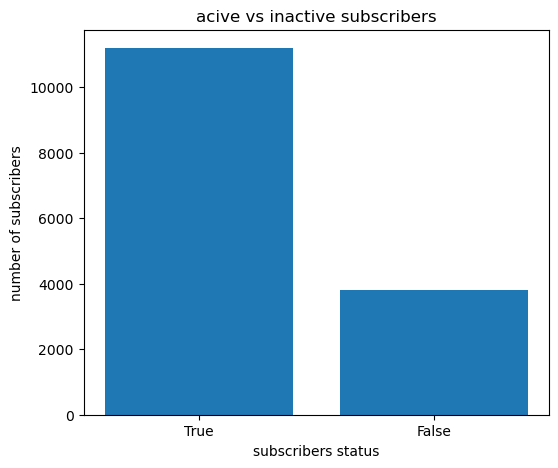

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))

plt.bar(active_counts.index.astype(str),
      active_counts.values)

plt.title("acive vs inactive subscribers")
plt.xlabel("subscribers status")
plt.ylabel("number of subscribers")

plt.show()

In [39]:
active_counts = subscribers["is_active"].value_counts()

In [40]:
print(active_counts)

True     11199
False     3801
Name: is_active, dtype: int64


In [42]:
active_percentage =(
subscribers["is_active"].value_counts(normalize=True)*100).round(2)
print(active_percentage)

True     74.66
False    25.34
Name: is_active, dtype: float64


## Business Insight

- Total Subscribers: **15,000**
- Active Subscribers: **11,199 (74.66%)**
- Inactive Subscribers: **3,801 (25.34%)**
- Approximately three out of every four subscribers are active.
- Around one in four subscribers has churned, indicating an opportunity to improve customer retention.

In [44]:
subscribers.columns

Index(['subscriber_id', 'signup_date', 'country', 'region', 'age', 'gender',
       'plan_type', 'monthly_price_usd', 'household_size', 'primary_device',
       'payment_method', 'tenure_months', 'is_active', 'churn_date'],
      dtype='object')

In [12]:
#Which subscriber plan is most popular

subscribers["plan_type"].value_counts()

Standard          6100
Basic with Ads    4458
Premium           4442
Name: plan_type, dtype: int64

In [48]:
plan_percentage=(
subscribers["plan_type"].value_counts(normalize=True)* 100).round(2)
print(plan_percentage)

Standard          40.67
Basic with Ads    29.72
Premium           29.61
Name: plan_type, dtype: float64


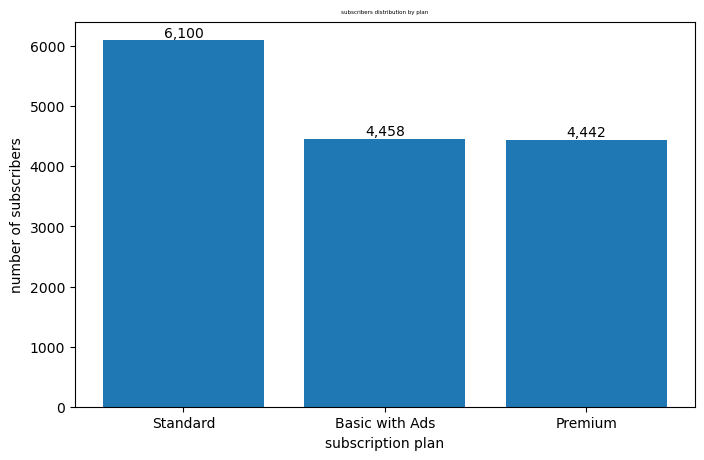

In [49]:
#create bar chart

plan_counts = subscribers["plan_type"].value_counts()
plt.figure(figsize=(8,5))
bars = plt.bar(
plan_counts.index,
plan_counts.values)

plt.title("subscribers distribution by plan",fontsize=4)
plt.xlabel("subscription plan")
plt.ylabel("number of subscribers")

for bar in bars:
    height = bar.get_height()
    plt.text(
    bar.get_x() + bar.get_width()/2,
    height + 50,
    f"{int(height):,}",
        ha = "center")
plt.show()    

## Business Insight

- The **Standard Plan** is the most popular subscription plan with **6,100 subscribers**.
- **Basic with Ads** and **Premium** have nearly equal subscriber counts.
- Around **40%** of subscribers prefer the Standard Plan.
- This suggests that customers perceive the Standard Plan as offering the best balance between price and features.

# StreamFlix Content Analytics Project

## 3. Exploratory Data Analysis (EDA)

### 3.1 Active vs Inactive Subscribers

### 3.1.2 Subscriber Distribution by Country

In [13]:
country_counts = subscribers["country"].value_counts()
print(country_counts)

United States     3774
India             1873
United Kingdom    1267
South Korea       1096
Japan              842
Brazil             835
Mexico             749
Spain              671
France             660
Germany            573
Canada             517
Italy              363
Turkey             310
Australia          263
Nigeria            251
Indonesia          228
Argentina          224
Thailand           195
Egypt              166
Sweden             143
Name: country, dtype: int64


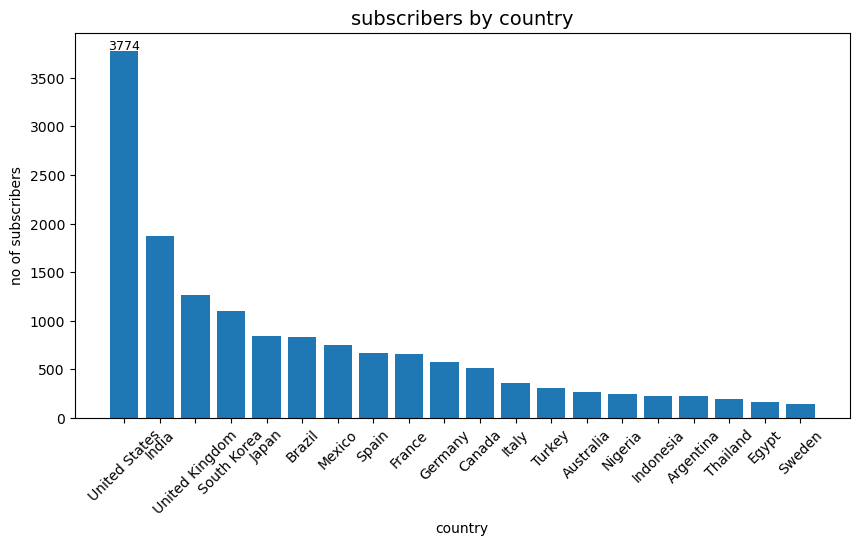

ValueError: Image size of 563x699718 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1059x475740 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1555x412538 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2047x318660 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2543x316073 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 3039x284287 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 3535x255458 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 4031x251393 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 4527x219238 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 5023x198540 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 5519x141622 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 6015x122033 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 6511x104662 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 7007x100226 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 7503x91726 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 7999x90247 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 8495x79529 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 8991x68810 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [15]:
#crezte bar chart
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
bars = plt.bar(
country_counts.index,
country_counts.values
)
plt.title("subscribers by country",fontsize=14)
plt.xlabel("country")
plt.ylabel("no of subscribers")

#show values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
    bar.get_x()+ bar.get_width()/2,
    height +20,
    f"{int(height)}",
        ha="center",
    fontsize=9
    )
    plt.xticks(rotation=45)
    plt.show()

In [16]:
country_counts = subscribers["country"].value_counts()
print(country_counts)

United States     3774
India             1873
United Kingdom    1267
South Korea       1096
Japan              842
Brazil             835
Mexico             749
Spain              671
France             660
Germany            573
Canada             517
Italy              363
Turkey             310
Australia          263
Nigeria            251
Indonesia          228
Argentina          224
Thailand           195
Egypt              166
Sweden             143
Name: country, dtype: int64


In [18]:
country_counts.head(10)

United States     3774
India             1873
United Kingdom    1267
South Korea       1096
Japan              842
Brazil             835
Mexico             749
Spain              671
France             660
Germany            573
Name: country, dtype: int64

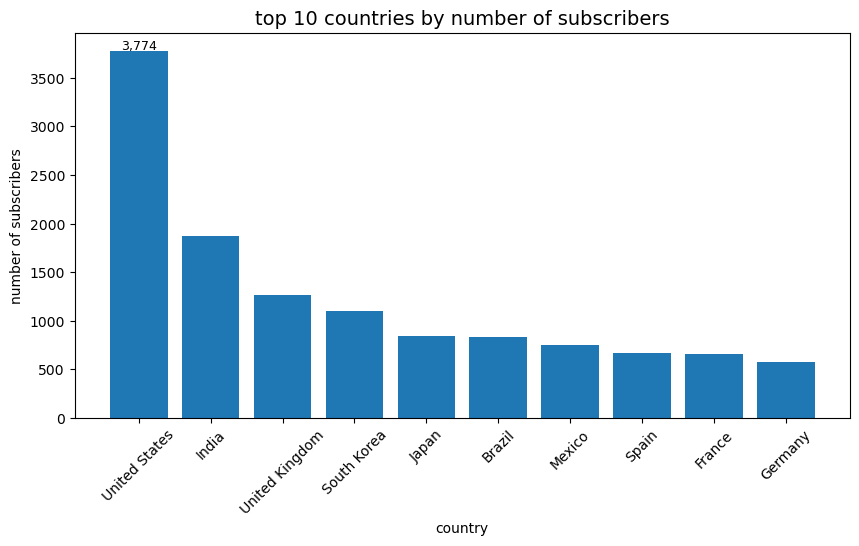

ValueError: Image size of 565x699718 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1061x475740 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1557x412538 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2047x318660 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2543x316073 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 3039x284287 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 3535x255458 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 4031x251393 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 4527x219238 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [19]:
plt.figure(figsize=(10,5))

bars = plt.bar(country_counts.head(10).index,
              country_counts.head(10).values)

plt.title("top 10 countries by number of subscribers",fontsize=14)
plt.xlabel("country")
plt.ylabel("number of subscribers")

for bar in bars:
    height = bar.get_height()
    plt.text(
    bar.get_x() + bar.get_width()/2,
    height + 20,
    f"{int(height):,}",
        ha = 'center',
        fontsize=9
    )
    plt.xticks(rotation =45)
    plt.show()

### Business Insight

- The United States has the highest number of subscribers (3,774), making it the platform's strongest market.
- India ranks second with 1,873 subscribers, indicating significant growth potential.
- The United Kingdom and South Korea also contribute a healthy subscriber base.
- StreamFlix can focus on localized content and marketing strategies in emerging markets to expand its global presence.

In [21]:
subscribers.groupby("plan_type")["monthly_price_usd"].mean()

plan_type
Basic with Ads     6.99
Premium           22.99
Standard          15.49
Name: monthly_price_usd, dtype: float64

In [22]:
revenue_by_plan = subscribers.groupby("plan_type")["monthly_price_usd"].sum()
print(revenue_by_plan)

plan_type
Basic with Ads     31161.42
Premium           102121.58
Standard           94489.00
Name: monthly_price_usd, dtype: float64


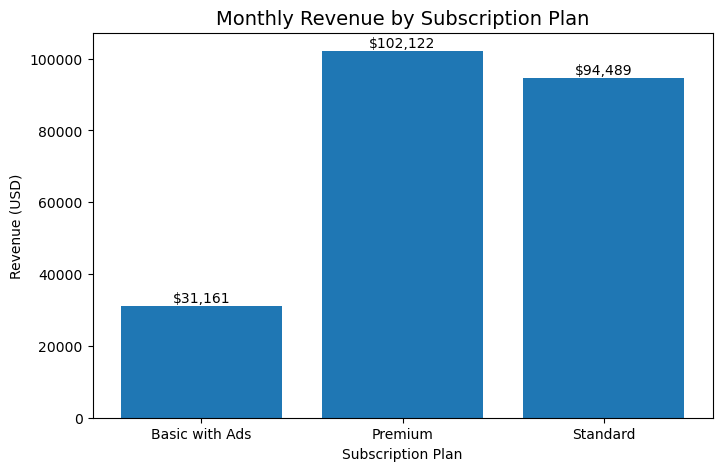

In [25]:
# creating revenue chart
plt.figure(figsize=(8,5))

bars = plt.bar(
    revenue_by_plan.index,
    revenue_by_plan.values
)

plt.title("Monthly Revenue by Subscription Plan", fontsize=14)
plt.xlabel("Subscription Plan")
plt.ylabel("Revenue (USD)")

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1000,
        f"${height:,.0f}",
        ha='center',
        fontsize=10
    )

plt.show()

### Business Insight

- The **Premium Plan** generates the highest monthly revenue (**$102,121.58**), despite having fewer subscribers than the Standard Plan.
- The **Standard Plan** has the largest subscriber base but ranks second in revenue due to its lower subscription price.
- The **Basic with Ads** plan contributes the least revenue and appears to target budget-conscious subscribers.
- StreamFlix should continue promoting Premium subscriptions while maintaining the Standard Plan as its core customer base.

In [27]:
#region distribution

region_counts = subscribers["region"].value_counts()
print(region_counts)

North America     4291
Europe            3677
East Asia         1938
South Asia        1873
Latin America     1808
Middle East        476
Southeast Asia     423
Oceania            263
Africa             251
Name: region, dtype: int64


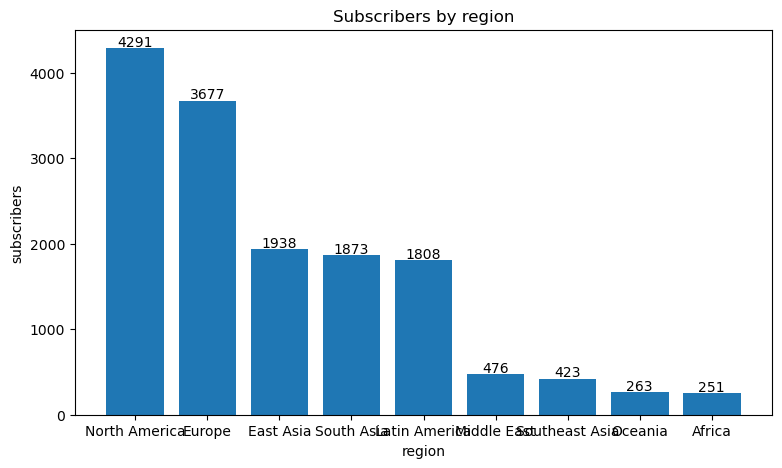

In [29]:
#make bar chart

plt.figure(figsize=(9,5))

bars = plt.bar(region_counts.index,
              region_counts.values)

plt.title("Subscribers by region")
plt.xlabel("region")
plt.ylabel("subscribers")

for bar in bars:
    plt.text(
    bar.get_x()+bar.get_width()/2,
    bar.get_height()+20,
    int(bar.get_height()),
    ha="center")
    

In [30]:
#GENDER DISTRIBUITON

gender_counts = subscribers["gender"].value_counts()
print(gender_counts)

Female         7276
Male           7128
Undisclosed     322
Non-binary      274
Name: gender, dtype: int64


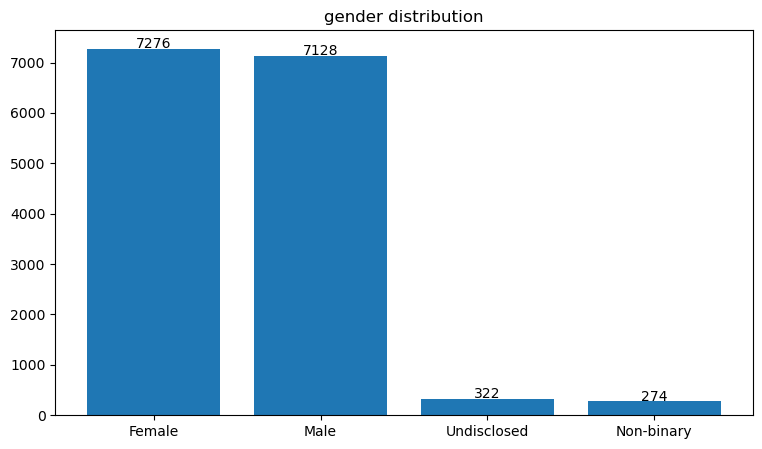

In [33]:
plt.figure(figsize=(9,5))

bars = plt.bar(gender_counts.index,
              gender_counts.values)
plt.title("gender distribution")

for bar in bars:
    plt.text(
    bar.get_x()+bar.get_width()/2,
    bar.get_height()+20,
    int(bar.get_height()),
    ha= "center")
    
plt.show()    

Text(0, 0.5, 'number of subscribers')

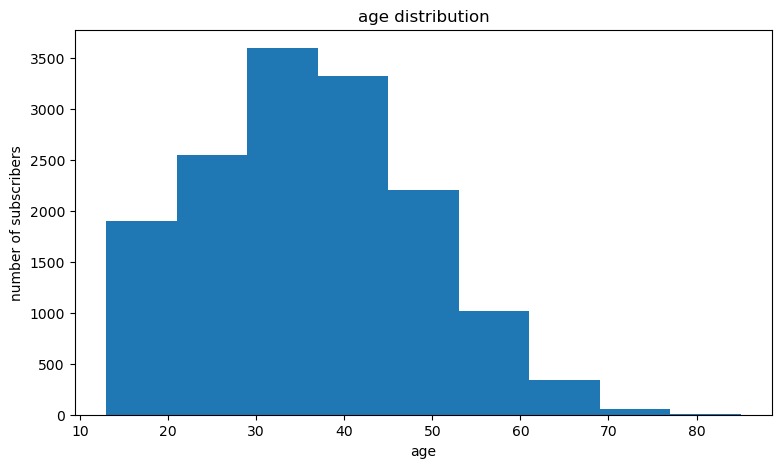

In [35]:
#AGE DISTRIBUUTION

plt.figure(figsize=(9,5))
plt.hist(subscribers["age"],bins=9)
plt.title("age distribution")
plt.xlabel("age")
plt.ylabel("number of subscribers")

In [38]:
#payment method

payment_counts= subscribers["payment_method"].value_counts()
print("payment_counts")

payment_counts


In [39]:
subscribers.head(4)

,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date
0,SUB100000,2023-01-09,France,Europe,22,Female,Basic with Ads,6.99,1,Mobile,Credit Card,41,True,NaN
1,SUB100001,2020-02-05,United Kingdom,Europe,48,Male,Basic with Ads,6.99,1,Smart TV,Credit Card,76,False,2022-12-08
2,SUB100002,2022-04-15,Italy,Europe,35,Male,Standard,15.49,2,Streaming Stick,Gift Card,50,True,NaN
3,SUB100003,2024-10-10,Spain,Europe,49,Female,Basic with Ads,6.99,1,Laptop,Credit Card,19,True,NaN


In [44]:
payment_counts = subscribers["payment_method"].value_counts()
print(payment_counts)


Credit Card        6332
Debit Card         3378
PayPal             1980
Mobile Wallet      1788
Gift Card           793
Carrier Billing     729
Name: payment_method, dtype: int64


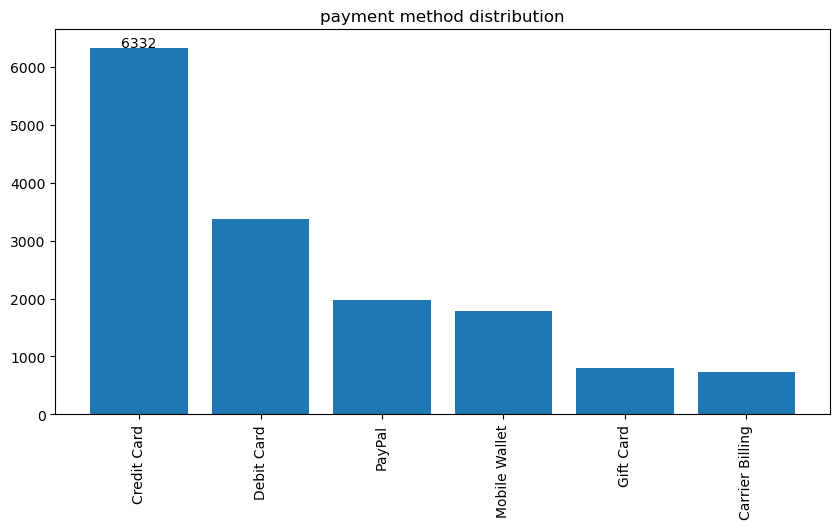

ValueError: Image size of 565x1255963 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1061x739262 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1557x668299 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2049x300547 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2545x276893 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [49]:
#make bar chart

plt.figure(figsize=(10,5))
bars=plt.bar(payment_counts.index,
            payment_counts.values)

plt.title("payment method distribution")

for bar in bars:
    plt.text(
    bar.get_x()+bar.get_width()/2,
    bar.get_height()+20,
    int(bar.get_height()),
        ha="center")
    plt.xticks(rotation=90)
    plt.show()

In [50]:
#primary device
device_counts=subscribers["primary_device"].value_counts()
print(device_counts)

Smart TV           5045
Mobile             4044
Laptop             2197
Tablet             1538
Game Console       1232
Streaming Stick     944
Name: primary_device, dtype: int64


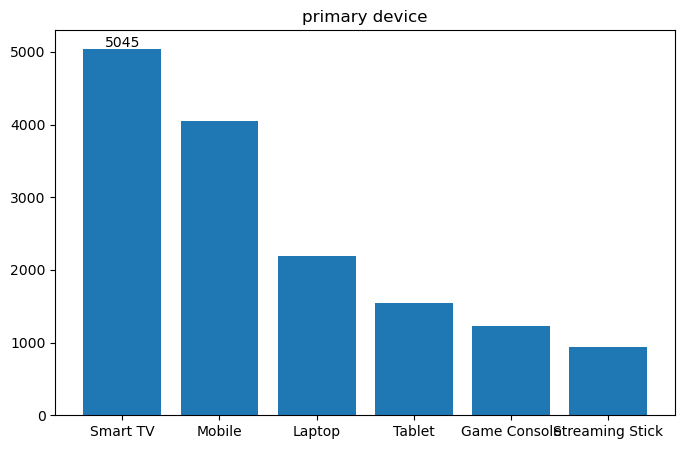

ValueError: Image size of 565x1502109 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1061x819457 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1557x575891 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2053x462793 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2545x356349 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [51]:
#chart
plt.figure(figsize=(8,5))
bars = plt.bar(device_counts.index,
              device_counts.values)

plt.title("primary device")
for bar in bars:
    plt.text(
    bar.get_x()+bar.get_width()/2,
    bar.get_height()+20,
    int(bar.get_height()),
    ha="center")
    
    plt.show()

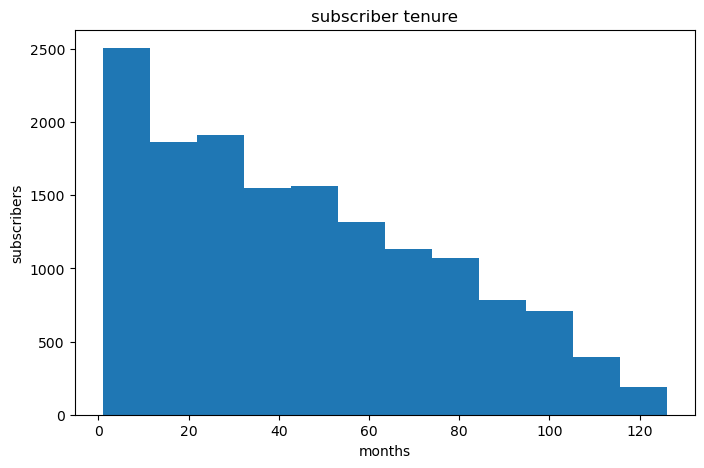

In [52]:
#tenure analysis

plt.figure(figsize=(8,5))
plt.hist(subscribers["tenure_months"],bins=12)
plt.title("subscriber tenure")
plt.xlabel("months")
plt.ylabel("subscribers")
plt.show()


In [53]:
#watch history
watch_history.groupby("device")["watch_duration_min"].mean()

device
Game Console       309.719340
Laptop             309.108056
Mobile             307.688273
Smart TV           307.092060
Streaming Stick    310.182464
Tablet             304.661681
Name: watch_duration_min, dtype: float64

In [56]:
watch_history.groupby("region")["watch_duration_min"].mean()

region
Africa            306.149456
East Asia         309.065813
Europe            308.061512
Latin America     306.241009
Middle East       305.752760
North America     308.031072
Oceania           309.977807
South Asia        306.692891
Southeast Asia    307.330682
Name: watch_duration_min, dtype: float64

In [57]:
watch_history.groupby("device")["completion_pct"].mean()

device
Game Console       65.305302
Laptop             65.366382
Mobile             65.271014
Smart TV           65.324256
Streaming Stick    65.233367
Tablet             65.339797
Name: completion_pct, dtype: float64

In [58]:
watch_history.groupby("region")["completion_pct"].mean()

region
Africa            65.532828
East Asia         65.464168
Europe            65.370548
Latin America     65.273507
Middle East       65.342885
North America     65.227482
Oceania           65.170045
South Asia        65.259165
Southeast Asia    65.284976
Name: completion_pct, dtype: float64

#EDA WATCH_HISTORY 

In [59]:
watch_history.columns

Index(['watch_id', 'subscriber_id', 'title_id', 'watch_date', 'device',
       'region', 'content_duration_min', 'watch_duration_min',
       'completion_pct', 'completed'],
      dtype='object')

In [60]:
device_counts = watch_history["device"].value_counts()
print(device_counts)

Smart TV           221446
Mobile             175605
Laptop              96408
Tablet              65276
Game Console        52322
Streaming Stick     38943
Name: device, dtype: int64


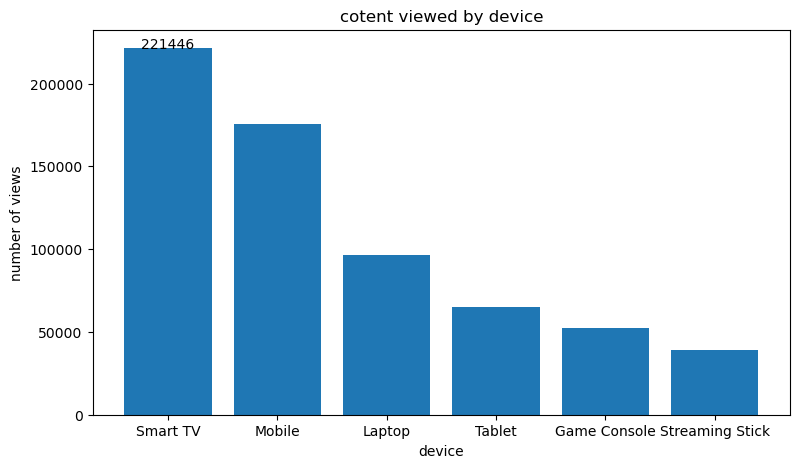

ValueError: Image size of 574x64940622 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1066x35669411 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1562x24163024 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2058x19375225 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2554x14430347 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [63]:
plt.figure(figsize=(9,5))
bars =  plt.bar(device_counts.index,device_counts.values)

plt.title("cotent viewed by device")
plt.xlabel("device")
plt.ylabel("number of views")

for bar in bars:
    plt.text(
    bar.get_x()+bar.get_width()/2,
    bar.get_height()+100,
    int(bar.get_height()),
    ha="center"
    
    )
    plt.show()

In [65]:
avg_watch = watch_history.groupby("device")["watch_duration_min"].mean()
print(avg_watch)

device
Game Console       309.719340
Laptop             309.108056
Mobile             307.688273
Smart TV           307.092060
Streaming Stick    310.182464
Tablet             304.661681
Name: watch_duration_min, dtype: float64


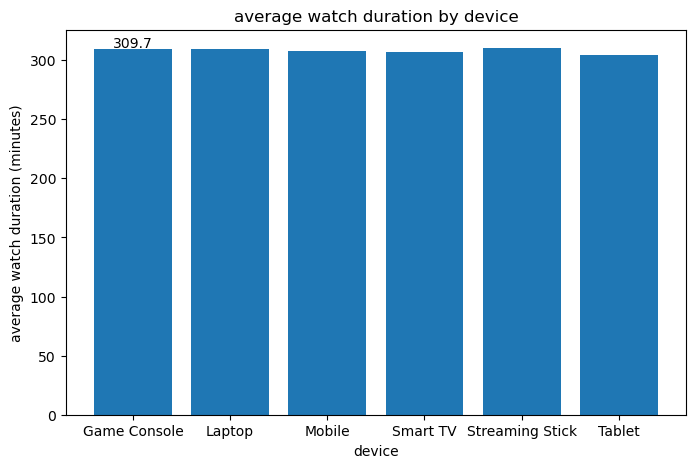

ValueError: Image size of 567x114670 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1063x114145 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 1559x113925 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2055x115067 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

ValueError: Image size of 2551x113027 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [67]:
plt.figure(figsize=(8,5))
bars = plt.bar(avg_watch.index,avg_watch.values)
plt.title("average watch duration by device")
plt.xlabel("device")
plt.ylabel("average watch duration (minutes)")

for bar in bars:
    plt.text(
    bar.get_x()+bar.get_width()/2,
    bar.get_height()+1,
    round(bar.get_height(),1),
    ha ="center")
    plt.show()

In [68]:
completion_region = watch_history.groupby("region")["completion_pct"].mean()

print(completion_region)

region
Africa            65.532828
East Asia         65.464168
Europe            65.370548
Latin America     65.273507
Middle East       65.342885
North America     65.227482
Oceania           65.170045
South Asia        65.259165
Southeast Asia    65.284976
Name: completion_pct, dtype: float64


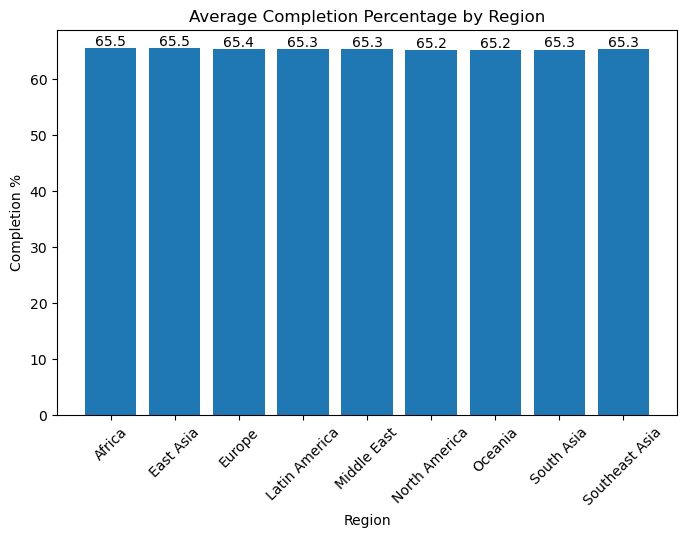

In [69]:
plt.figure(figsize=(8,5))

bars = plt.bar(completion_region.index, completion_region.values)

plt.title("Average Completion Percentage by Region")
plt.xlabel("Region")
plt.ylabel("Completion %")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        round(bar.get_height(),1),
        ha="center"
    )

plt.xticks(rotation=45)

plt.show()

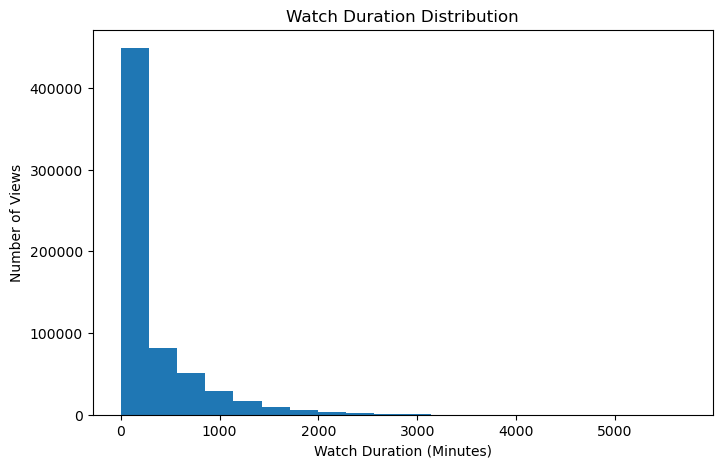

In [70]:
plt.figure(figsize=(8,5))

plt.hist(watch_history["watch_duration_min"], bins=20)

plt.title("Watch Duration Distribution")
plt.xlabel("Watch Duration (Minutes)")
plt.ylabel("Number of Views")

plt.show()

In [71]:
# which device has highest content completion?

completion_device = watch_history.groupby("device")["completion_pct"].mean()
print(completion_device)

device
Game Console       65.305302
Laptop             65.366382
Mobile             65.271014
Smart TV           65.324256
Streaming Stick    65.233367
Tablet             65.339797
Name: completion_pct, dtype: float64


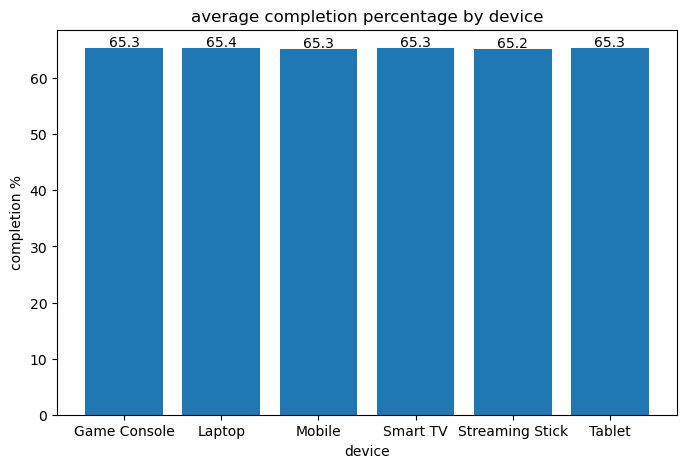

In [72]:
plt.figure(figsize=(8,5))
bars = plt.bar(completion_device.index,
              completion_device.values)

plt.title("average completion percentage by device")
plt.xlabel("device")
plt.ylabel("completion %")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3,
            round(bar.get_height(),1),
            ha="center")
plt.show()    

# Indicates user engagement does not vary significantly by device

In [2]:
#Content Anaalysis
titles.columns

NameError: name 'titles' is not defined

In [1]:
#movies vs tv shows

content_type=titles["type"].value_counts()
print(content)

NameError: name 'titles' is not defined

In [7]:
subscribers.to_csv("cleaned_subscribers.csv",index=False)

titles.to_csv("cleaned_titles.csv",index=False)

watch_history.to_csv("cleaned_watch_history.csv",index=False)

ratings.to_csv("cleaned_ratings.csv",index=False)

reviews.to_csv("cleaned_reviews.csv",index=False)

watchlist.to_csv("cleaned_watchlist.csv",index=False)

In [8]:
import sqlite3

In [9]:
conn=sqlite3.connect("streamflix.db")

In [10]:
subscribers.to_sql("subscribers",conn,index=False,if_exists="replace")

15000

In [11]:
titles.to_sql("titles",conn,index=False,if_exists="replace")

9000

In [14]:
watch_history.to_sql("watch_history",conn,index=False,if_exists="replace")

650000

In [16]:
ratings.to_sql("ratings",conn,index=False,if_exists="replace")

130000

In [17]:
reviews.to_sql("reviews",conn,index=False,if_exists="replace")

110000

In [18]:
watchlist.to_sql("watchlist",conn,index=False,if_exists="replace")

65000

In [19]:
#SQL Question 

#Total Subscribers

query="""
SELECT COUNT(*)AS TOTALSUBSCRIBERS
FROM subscribers
"""
pd.read_sql(query,conn)


,TOTALSUBSCRIBERS
0,15000


In [21]:
#ACTIVE SUBRSCRIBERS

query="""
select is_active,Count(*) as Subscribers
from subscribers
group by is_active"""

pd.read_sql(query,conn)

,is_active,Subscribers
0,0,3801
1,1,11199


In [27]:
#Revenue by plan

query="""
SELECT
plan_type,SUM(monthly_price_usd) AS Revenue
from subscribers
group by plan_type
order by Revenue DESC"""
pd.read_sql(query,conn)

,plan_type,Revenue
0,Premium,102121.58
1,Standard,94489.00
2,Basic with Ads,31161.42


In [28]:
#TOP 10 MOST WATCHED TITLES

query="""
select title_id,count(*)as views
from watch_history
group by title_id
order by views desc
limit 10"""
pd.read_sql(query,conn)

,title_id,views
0,TTL205962,4436
1,TTL207141,4358
2,TTL203531,3482
3,TTL206337,3028
4,TTL207554,2476
5,TTL202855,1927
6,TTL206938,1792
7,TTL204514,1792
8,TTL204462,1681
9,TTL205320,1513


In [32]:
#TOP 10 COUNTRIES
query="""
select country,count(*)as Subscribers
from subscribers
group by country
order by Subscribers DESC
LIMIT 10"""

pd.read_sql(query,conn)

,country,Subscribers
0,United States,3774
1,India,1873
2,United Kingdom,1267
3,South Korea,1096
4,Japan,842
5,Brazil,835
6,Mexico,749
7,Spain,671
8,France,660
9,Germany,573


In [ ]:
query="""
select device,round(avg(watch_duration_min),2)AS avgwatchduration from watch_history
order by AvgWatchDuration desc"""
pd.read_sql(query,conn)

,device,avgwatchduration
0,Smart TV,307.7


In [35]:
query="""
select sentiment,count(*)as Reviews
from reviews
group by sentiment"""
pd.read_sql(query,conn)

,sentiment,Reviews
0,Negative,12234
1,Neutral,22759
2,Positive,75007


In [37]:
#watchlist status
query="""
select watched,count(*)as Count from watchlist group by watched"""
pd.read_sql(query,conn)

,watched,Count
0,0,34952
1,1,30048
